# From fitting a trajectory to fitting a transition function

In [86]:
%loadlibs
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
from scipy.integrate import solve_ivp
torch.set_default_device('mps')

Loaded libraries:
	- numpy (np)
	- matplotlib.pyplot (plt)
	- torch
	- torch.nn (nn)
	- torch.optim (optim)
	- tqdm


Training a PINN for learning a dynamical system 
$$\dot{x}(t) = f(x(t))$$
consists in learning a transition function
$$x(t) = \phi(t, t_0, x(t_0)),$$
where $x(t)$ is a solution of the first equation. To do so, classically, in the literature, one trains a MLP $f^{\text{NN}}(x)$ such that
$$\dot{f^{\text{NN}}} = f,$$
or
$$\frac{\partial f^{\text{NN}}}{\partial t} = f.$$
However, additional constraint can usually be inferred from the initial system:
- Consistency: $\phi(t, t, x(t)) = x$,
- Composition: $\phi(t_2, t_0, x(t_0)) = \phi(t_2, t_1, \phi(t_1, t_0, x(t_0)))$,
- Stationarity: $\phi(t, t_0, x(t_0)) = \phi(t+\delta t, t_0+\delta t, x(t_0))$.

In this work, we show:
1. The learned trajectories are qualitatively and quantitatively correct before adding the new constraints
2. The learned phase portrait is not correct
3. Adding new constraints allows for correcting the phase portrait

## One-dimensional case
We work with a system described by
$$\dot{x}(t) = a x(t),$$
with $a>0$.

In [87]:
def plot_phase_line(f, ax, xlim=(-4, 4), n_scan=2000):
    xmin, xmax = xlim
    xs = np.linspace(xmin, xmax, n_scan)
    fs = f(np.zeros(xs.shape), xs)
    bounds = [xmin, xmax]
    ax.hlines(0, xmin, xmax, color='black')
    for lo, hi in zip(bounds[:-1], bounds[1:]):
        for x0 in np.linspace(lo, hi, 7)[1:-1]:
            d = np.sign(f(0, x0))
            if d != 0:
                ax.arrow(x0, 0, 0.1 * d, 0, head_width=0.03, head_length=0.08,
                          length_includes_head=True, color='green')

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(-0.1, 0.1)
    ax.set_yticks([])
    ax.set_xlabel(r"$x$")
    ax.grid(axis='x')
    return ax

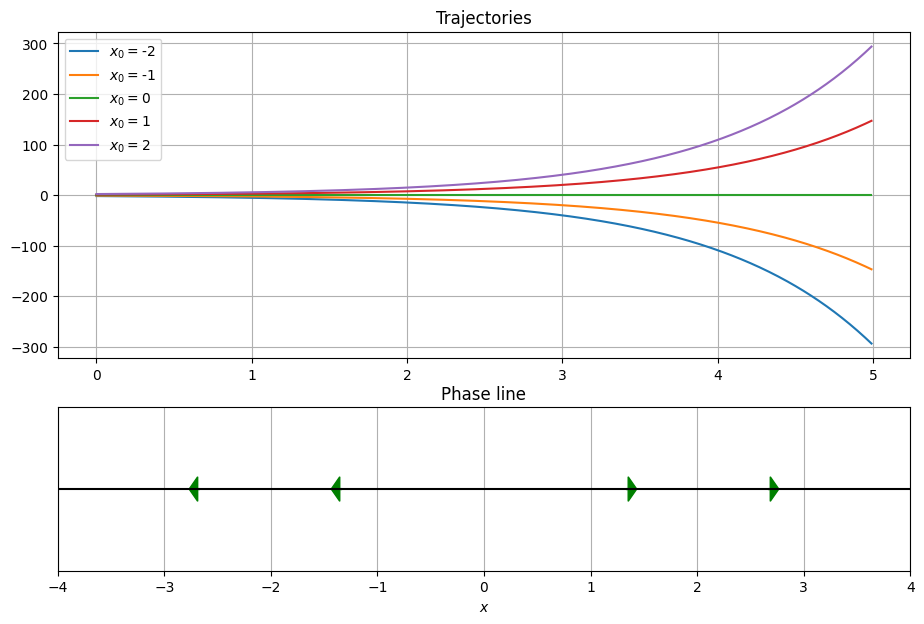

In [88]:
T_MAX = 5.
t_eval = np.arange(0, T_MAX, 0.01)
a = 1.
def f(t, x):
    return a * x

x0s = [-2, -1, 0, 1, 2]
solutions = solve_ivp(f, [0, T_MAX], x0s, t_eval=t_eval).y

fig, ax = plt.subplots(2, 1, figsize=(11, 7), height_ratios=[2, 1])
for sol, x0 in zip(solutions, x0s):
    ax[0].plot(t_eval, sol, label=r"$x_0=$"+f"{x0}")
ax[0].grid('on')
ax[0].set_title("Trajectories")
ax[0].legend()
plot_phase_line(f, ax[1])
ax[1].set_title("Phase line")
plt.show()

We then train a PINN for each trajectory, with hard constraint.

In [93]:
class PINN(nn.Module):
    def __init__(self, x0, layer_size=32):
        super().__init__()
        self.x0 = x0
        self.l1 = nn.Linear(1, layer_size)
        self.l2 = nn.Linear(layer_size, layer_size)
        self.l3 = nn.Linear(layer_size, layer_size)
        self.l4 = nn.Linear(layer_size, layer_size)
        self.l6 = nn.Linear(layer_size, 1)
        self.activation = nn.Tanh()

    def forward(self, t):
        x = self.activation(self.l1(t))
        x = self.activation(self.l2(x))
        x = self.activation(self.l3(x))
        x = self.activation(self.l4(x))
        return t * self.l6(x) + self.x0

In [94]:
def loss_fn(model, t):
    x = model(t)
    dxdt = torch.autograd.grad(x, t, grad_outputs=torch.ones_like(t), create_graph=True)[0]
    return ((dxdt - a*x)**2).mean()

In [6]:
n_points = 5000
n_epochs = 5000

models = [PINN(x0) for x0 in x0s]
for model in models:
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    
    for _ in (pbar:=tqdm(range(n_epochs))):
        optimizer.zero_grad()
        t = torch.rand((n_points, 1), requires_grad=True) * T_MAX
        loss = loss_fn(model, t)
        loss.backward()
        optimizer.step()
        pbar.set_description(f"Loss: {loss.item():.4e}")

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

We plot the trajectories:

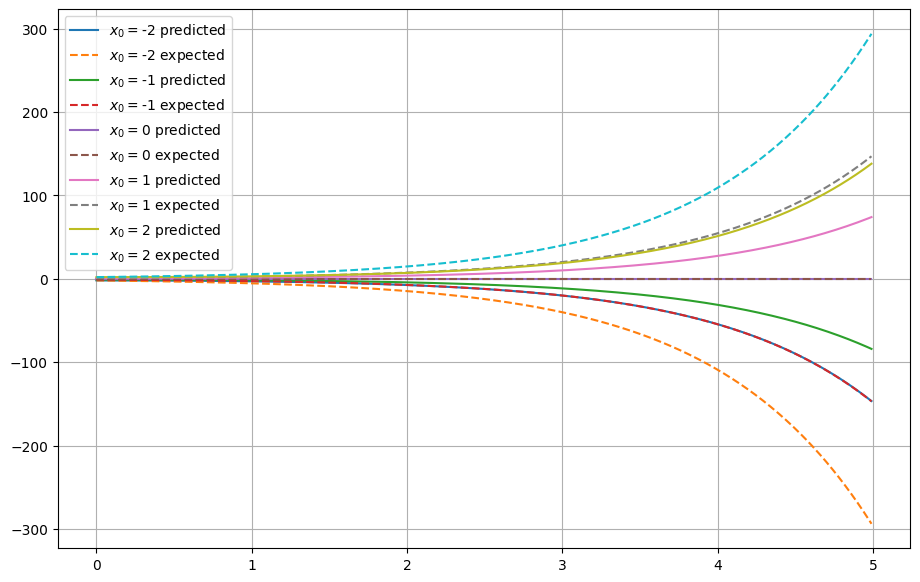

In [7]:
t = torch.tensor(t_eval, dtype=torch.float32).unsqueeze(-1)
plt.figure(figsize=(11, 7))
for model, x0, sol in zip(models, x0s, solutions):
    plt.plot(t.cpu().numpy(), model(t).squeeze().detach().cpu().numpy(), label=r"$x_0=$"+f"{x0} predicted")
    plt.plot(t_eval, sol, linestyle='dashed', label=r"$x_0=$"+f"{x0} expected")
plt.legend()
plt.grid()
plt.show()

The trajectories match. However, it is required to train a new PINN for each initial condition, rather, we can pass the initial condition as additional input, and feed it to the Neural Network. Therefore, we try to learn the transition function $x(t) = \phi(t, t_0, x(t_0))$ which satisfies the initial equation.

In [90]:
class TransitionPINN(nn.Module):
    def __init__(self, layer_size=32):
        super().__init__()
        self.l1 = nn.Linear(3, layer_size)
        self.l2 = nn.Linear(layer_size, layer_size)
        self.l3 = nn.Linear(layer_size, layer_size)
        self.l4 = nn.Linear(layer_size, layer_size)
        self.l6 = nn.Linear(layer_size, 1)
        self.activation = nn.Tanh()

    def forward(self, t, t0, x0):
        inputs = torch.concatenate([t, t0, x0], axis=-1)
        x = self.activation(self.l1(inputs))
        x = self.activation(self.l2(x))
        x = self.activation(self.l3(x))
        x = self.activation(self.l4(x))
        return (t-t0) * self.l6(x) + x0

In [91]:
def loss_fn(model, t, t0, x0):
    x = model(t, t0, x0)
    dxdt = torch.autograd.grad(x, t, grad_outputs=torch.ones_like(t), create_graph=True)[0]
    return ((dxdt - a*x)**2).mean()

In [10]:
model = TransitionPINN()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
for _ in (pbar:=tqdm(range(n_epochs))):
    optimizer.zero_grad()
    t0 = torch.rand((n_points, 1), requires_grad=True) * T_MAX
    t = t0 + torch.rand((n_points, 1), requires_grad=True) * (T_MAX-t0)
    x0 = (torch.rand((n_points, 1), requires_grad=True)-0.5) * 8.
    loss = loss_fn(model, t, t0, x0)
    loss.backward()
    optimizer.step()
    pbar.set_description(f"Loss: {loss.item():.4e}")

  0%|          | 0/5000 [00:00<?, ?it/s]

Which yields the following trajectories:

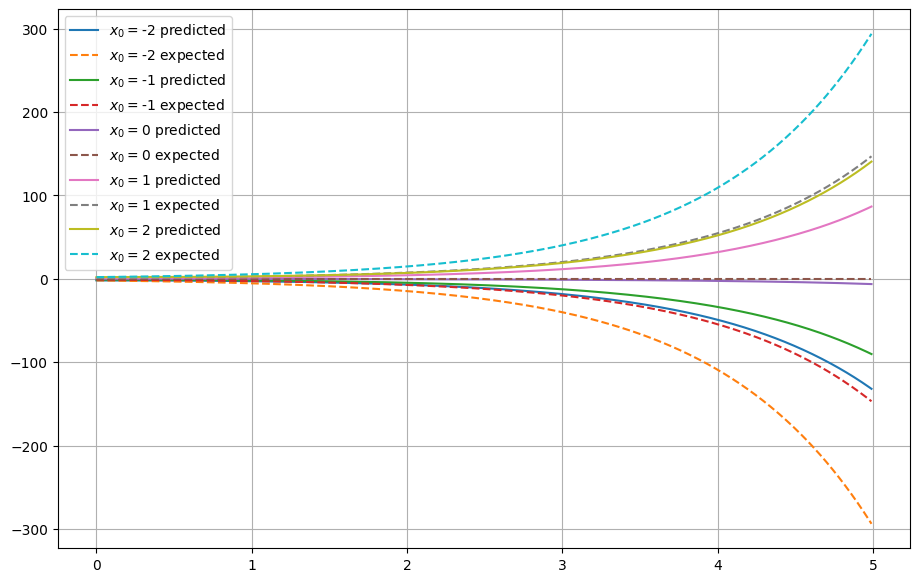

In [11]:
t = torch.tensor(t_eval, dtype=torch.float32).unsqueeze(-1)
plt.figure(figsize=(11, 7))
for x0, sol in zip(x0s, solutions):
    plt.plot(t.cpu().numpy(), model(t, torch.zeros_like(t), torch.ones_like(t)*x0).squeeze().detach().cpu().numpy(), label=r"$x_0=$"+f"{x0} predicted")
    plt.plot(t_eval, sol, linestyle='dashed', label=r"$x_0=$"+f"{x0} expected")
plt.legend()
plt.grid()
plt.show()

And we see that the trajectories are correct.

In [92]:
def plot_phase_line_trough_time(f, t, xlim=(-4, 4), n_scan=100):
    plt.figure(figsize=(11, 3))
    xmin, xmax = xlim
    xs = torch.linspace(xmin, xmax, n_scan).unsqueeze(-1)
    fs = f(torch.ones_like(xs), torch.ones_like(xs), xs).detach().cpu().numpy().squeeze()
    bounds = [xmin, xmax]
    plt.hlines(0, xmin, xmax, color='black')
    for lo, hi in zip(bounds[:-1], bounds[1:]):
        for x0 in np.linspace(lo, hi, 20)[1:-1]:
            t = torch.tensor([t], dtype=torch.float32, requires_grad=True).unsqueeze(-1)
            f_x0 = f(t, torch.ones_like(t)*t.detach(), torch.tensor([x0], dtype=torch.float32).unsqueeze(-1))
            df_x0_dt = torch.autograd.grad(f_x0, t, grad_outputs=torch.ones_like(t), create_graph=True)[0]
            d = np.sign(df_x0_dt.detach().cpu().squeeze().numpy())
            if d != 0:
                plt.arrow(x0, 0, 0.1 * d, 0, head_width=0.03, head_length=0.08, length_includes_head=True, color='green')
    plt.xlim(xmin, xmax)
    plt.ylim(-0.1, 0.1)
    plt.yticks([])
    plt.xlabel(r"$x$")
    plt.grid(axis='x')

for t in np.arange(0, T_MAX, 0.5):
    plot_phase_line_trough_time(model, t)

TypeError: TransitionPINN.forward() missing 1 required positional argument: 'x2_0'

<Figure size 1100x300 with 0 Axes>

We see that the phase portrait is not always correct.

## 2-dimensional case
We work with a linear, stationary system
\begin{equation}
    \begin{cases}
        \dot{x}_1 &= a_{00} x_1 + a_{01} x_2\\
        \dot{x}_2 &= a_{10} x_1 + a_{11} x_2 
    \end{cases}
\end{equation}
where the matrix $A = \begin{bmatrix}a_{00}& a_{01}\\a_{10}&a_{11}\end{bmatrix}$ is the coefficient matrix.

In [124]:
def true_trajectory_A(A: list[list], interval: list[int], c_i: list[int]) -> None:
    def xdot(t, x):
        return A @ x
    sol = solve_ivp(xdot, interval, c_i, t_eval=np.linspace(interval[0], interval[1], 250))
    plt.plot(sol.y[0, :], sol.y[1, :], label="Trajectoire ("+r"$x(0)$"+f" = {c_i})")
    plt.xlabel(r"$x_1$")
    plt.ylabel(r"$x_2$")
    plt.legend()

def true_phase_portrait_A(A, ax=None):
    x1, x2 = np.meshgrid(np.arange(-1.5, 1.6, 0.2), np.arange(-1.5, 1.6, 0.2))
    x1_values = A[0,0]*x1 + A[0,1]*x2
    x2_values = A[1,0]*x1 + A[1,1]*x2

    norms = np.sqrt(x1_values**2 + x2_values**2)
    x1_normalized = x1_values / norms
    x2_normalized = x2_values / norms

    vector_scale = 25
    if not ax:
        plt.quiver(x1, x2, x1_normalized, x2_normalized, scale=vector_scale)
        plt.xlim([-1.5, 1.5])
        plt.ylim([-1.5, 1.5])
        plt.grid()
    else:
        ax.quiver(x1, x2, x1_normalized, x2_normalized, scale=vector_scale)
        ax.set_xlim([-1.5, 1.5])
        ax.set_ylim([-1.5, 1.5])
        ax.set_title("Reference")

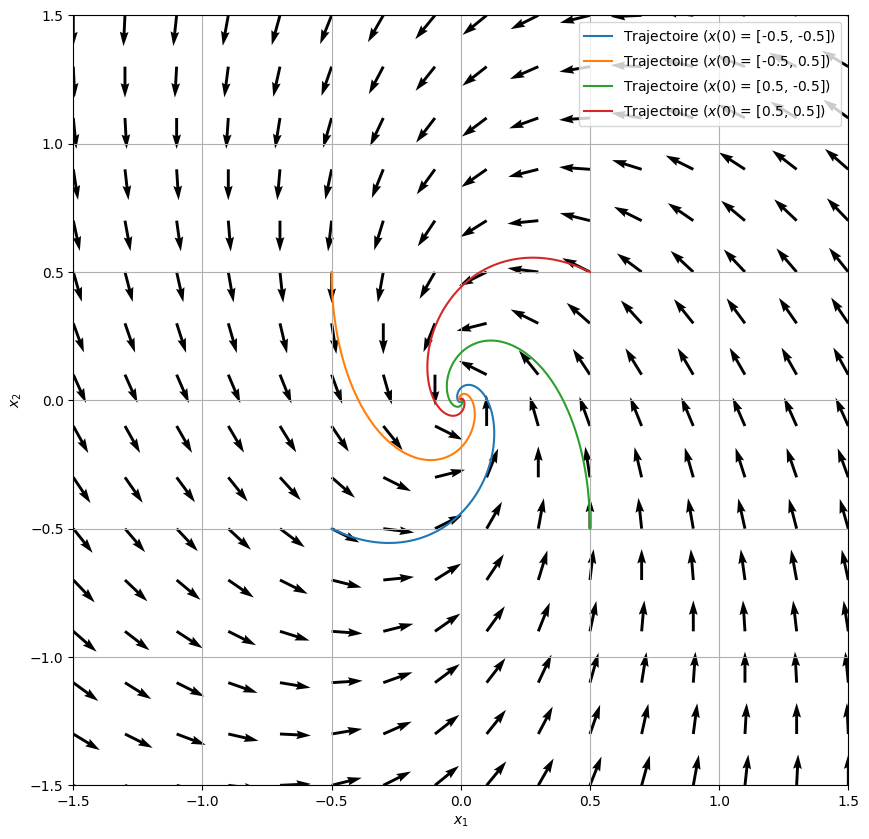

In [125]:
A = np.array([[-1, -1], [2, -1]])
c_is = [[-0.5,-0.5], [-0.5,0.5], [0.5,-0.5], [0.5,0.5]]

plt.figure(figsize=(10, 10))
for c_i in c_is:
    true_trajectory_A(A, (0, T_MAX), c_i)

true_phase_portrait_A(A)

In [97]:
class TransitionPINN_A(nn.Module):
    def __init__(self, layer_size=32):
        super().__init__()
        self.l1 = nn.Linear(4, layer_size)
        self.l2 = nn.Linear(layer_size, layer_size)
        self.l3 = nn.Linear(layer_size, layer_size)
        self.l6 = nn.Linear(layer_size, 2)
        self.activation = nn.Tanh()

    def forward(self, t, t0, x1_0, x2_0):
        inputs = torch.concatenate([t, t0, x1_0, x2_0], axis=-1)
        x = self.activation(self.l1(inputs))
        x = self.activation(self.l2(x))
        x = self.activation(self.l3(x))
        return (t-t0) * self.l6(x) + torch.concatenate([x1_0, x2_0], axis=-1)

def loss_physics_A(model, t, t0, x1_0, x2_0):
    x1x2 = model(t, t0, x1_0, x2_0)
    x1, x2 = x1x2[:, 0:1], x1x2[:, 1:2]
    dx1_dt = torch.autograd.grad(x1, t, grad_outputs=torch.ones_like(t), create_graph=True)[0]
    dx2_dt = torch.autograd.grad(x2, t, grad_outputs=torch.ones_like(t), create_graph=True)[0]
    loss_x1 = ((dx1_dt - (A[0,0]*x1 + A[0,1]*x2))**2).mean()
    loss_x2 = ((dx2_dt - (A[1,0]*x1 + A[1,1]*x2))**2).mean()
    return loss_x1 + loss_x2

In [142]:
n_points = 5000
n_epochs = 10000

torch.random.manual_seed(0)
model_A = TransitionPINN_A()
optimizer = optim.Adam(model_A.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=200, min_lr=1e-5)
for _ in (pbar:=tqdm(range(n_epochs))):
    optimizer.zero_grad()
    t0 = torch.rand((n_points, 1), requires_grad=True) * T_MAX
    t = t0 + torch.rand((n_points, 1), requires_grad=True) * (T_MAX-t0)
    x1_0 = (torch.rand((n_points, 1), requires_grad=True)-0.5) * 8.
    x2_0 = (torch.rand((n_points, 1), requires_grad=True)-0.5) * 8.
    loss = loss_physics_A(model_A, t, t0, x1_0, x2_0)
    loss.backward()
    optimizer.step()
    scheduler.step(loss.item())
    pbar.set_description(f"Loss: {loss.item():.4e}")

  0%|          | 0/10000 [00:00<?, ?it/s]

In [143]:
def model_trajectory(model, interval: list[int], c_i: list[int]) -> None:
    t_eval = torch.linspace(interval[0], interval[1], 250).unsqueeze(-1)
    x1x2 = model(t_eval, torch.zeros_like(t_eval), torch.ones_like(t_eval)*c_i[0], torch.ones_like(t_eval)*c_i[1]).detach().cpu().squeeze().numpy()
    x1, x2 = x1x2[:, 0], x1x2[:, 1]
    plt.plot(x1, x2, label="Trajectoire ("+r"$x(0)$"+f" = {c_i})")
    plt.xlabel(r"$x_1$")
    plt.ylabel(r"$x_2$")
    plt.legend()

def model_phase_portrait(model, ax, t=1.,):
    x1_0, x2_0 = torch.meshgrid(torch.arange(-1.5, 1.6, 0.2), torch.arange(-1.5, 1.6, 0.2))
    x1_0 = x1_0.flatten().unsqueeze(-1)
    x2_0 = x2_0.flatten().unsqueeze(-1)
    t = torch.ones_like(x1_0, requires_grad=True)*t
    x1x2 = model(t, t.detach(), x1_0, x2_0)
    x1, x2 = x1x2[:, 0:1], x1x2[:, 1:2]
    x1_values = torch.autograd.grad(x1, t, grad_outputs=torch.ones_like(t), create_graph=True)[0].cpu().detach().squeeze().numpy()
    x2_values = torch.autograd.grad(x2, t, grad_outputs=torch.ones_like(t), create_graph=True)[0].cpu().detach().squeeze().numpy()

    norms = np.sqrt(x1_values**2 + x2_values**2)
    x1_normalized = x1_values / norms
    x2_normalized = x2_values / norms

    vector_scale = 25
    ax.quiver(x1_0.cpu().detach().squeeze(), x2_0.cpu().detach().squeeze(), x1_normalized, x2_normalized, scale=vector_scale, color='gray')
    ax.set_xlim([-1.5, 1.5])
    ax.set_ylim([-1.5, 1.5])
    ax.set_title(f"t: {t[0].item()}")

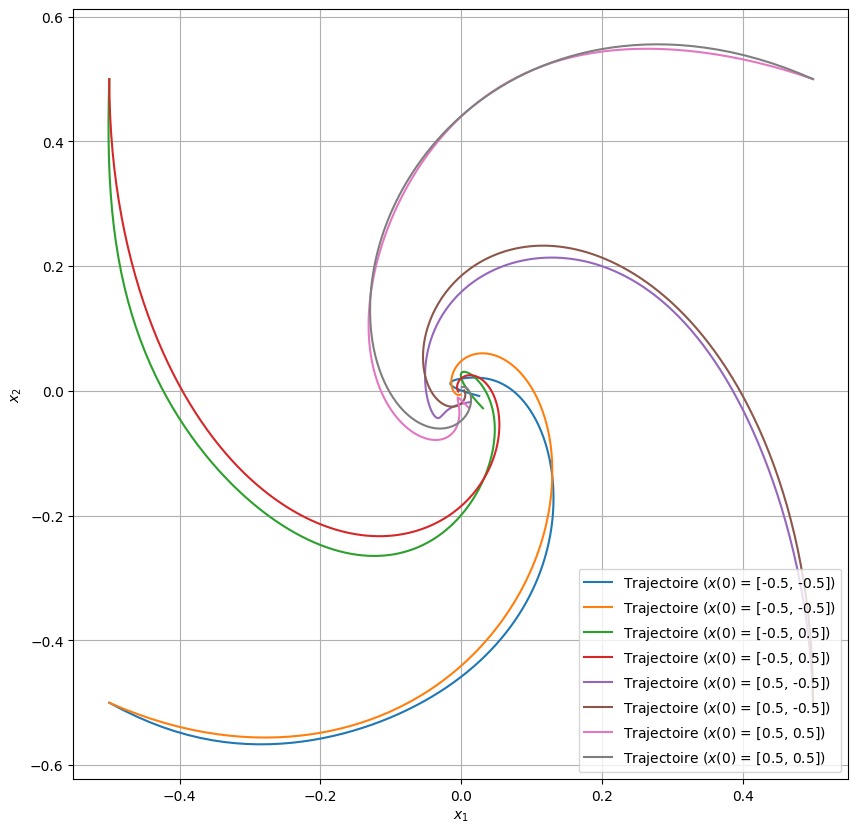

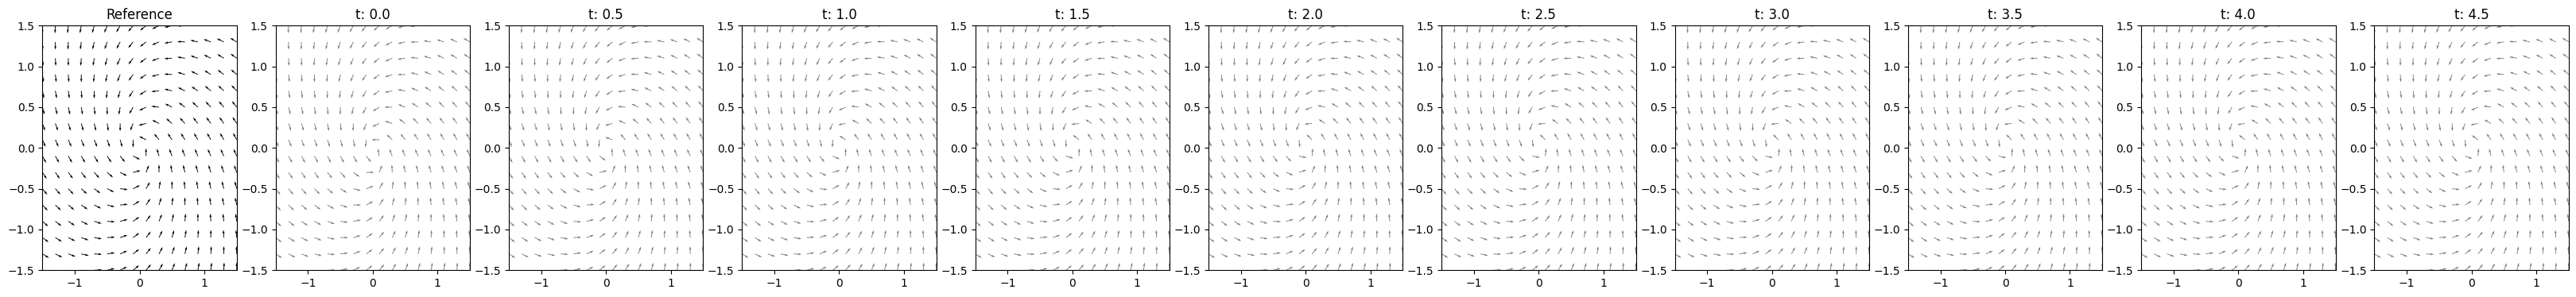

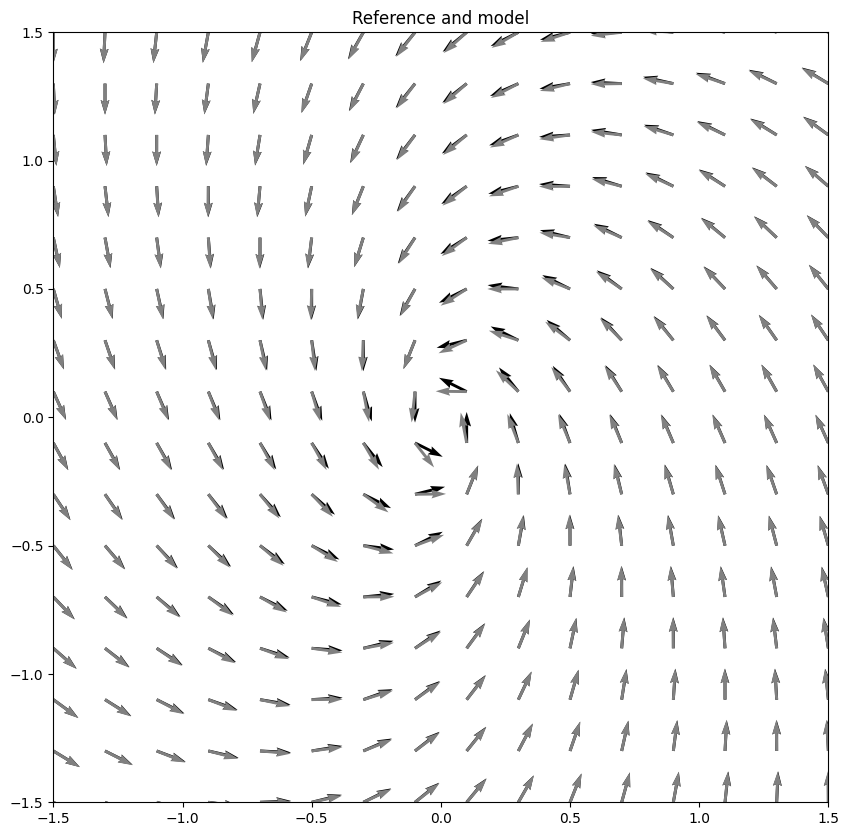

In [152]:
plt.figure(figsize=(10, 10))
for c_i in c_is:
    model_trajectory(model_A, (0, T_MAX), c_i)
    true_trajectory_A(A, (0, T_MAX), c_i)
plt.grid()
plt.savefig('trajectories_pinn.jpg')
plt.show()
fig, ax = plt.subplots(1, int(T_MAX*2)+1, figsize=(T_MAX*2*4 + 1, 4))
true_phase_portrait_A(A, ax[0])
for t in np.arange(0, T_MAX, .5):
    model_phase_portrait(model_A, ax[int(t*2)+1], t)
plt.savefig('phase_portrait_through_time_pinn.jpg')
plt.show()
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
true_phase_portrait_A(A, ax)
model_phase_portrait(model_A, ax, 0)
ax.set_title("Reference and model")
plt.savefig('phase_portrait_pinn.jpg')
plt.show()

- Consistency: $\phi(t, t, x(t)) = x$,
- Composition: $\phi(t_2, t_0, x(t_0)) = \phi(t_2, t_1, \phi(t_1, t_0, x(t_0)))$,
- Stationarity: $\phi(t, t_0, x(t_0)) = \phi(t+\delta t, t_0+\delta t, x(t_0))$.

In [145]:
class TransitionPINN_A2(nn.Module):
    def __init__(self, layer_size=32):
        super().__init__()
        self.l1 = nn.Linear(3, layer_size)
        self.l2 = nn.Linear(layer_size, layer_size)
        self.l3 = nn.Linear(layer_size, layer_size)
        self.l6 = nn.Linear(layer_size, 2)
        self.activation = nn.Tanh()

    def forward(self, t, t0, x1_0, x2_0):
        tau = t - t0
        inputs = torch.concatenate([tau, x1_0, x2_0], axis=-1)
        x = self.activation(self.l1(inputs))
        x = self.activation(self.l2(x))
        x = self.activation(self.l3(x))
        return tau * self.l6(x) + torch.concatenate([x1_0, x2_0], axis=-1)

In [146]:
def consistency_loss(model, t0, x1_0, x2_0):
    x1x2 = model(t0, t0, x1_0, x2_0)
    return ((x1x2-torch.concatenate([x1_0, x2_0], axis=-1))**2).mean()

def composition_loss(model, t, t0, t1, x1_0, x2_0):
    x1 = model(t, t0, x1_0, x2_0)
    x1x2_1 = model(t1, t0, x1_0, x2_0)
    x1_1, x2_1 = x1x2_1[:, 0:1].detach(), x1x2_1[:, 1:2].detach()
    x2 = model(t, t1, x1_1, x2_1)
    return ((x2-x1)**2).mean()

def stationarity_loss(model, t, t0, x1_0, x2_0, dt):
    x1x2 = model(t, t0, x1_0, x2_0)
    x1x2_dt = model(t+dt, t0+dt, x1_0, x2_0)
    return ((x1x2-x1x2_dt)**2).mean()

def derivative_stationarity_loss(model, t, t0, x1_0, x2_0, dt):
    x1x2 = model(t, t0, x1_0, x2_0)
    x1, x2 = x1x2[:, 0:1], x1x2[:, 1:2]
    x1x2_dt = model(t+dt, t0+dt, x1_0, x2_0)
    x1_dt, x2_dt = x1x2_dt[:, 0:1], x1x2_dt[:, 1:2]
    dx1 = torch.autograd.grad(x1, t, grad_outputs=torch.ones_like(t), create_graph=True)[0]
    dx1dt = torch.autograd.grad(x1_dt, t, grad_outputs=torch.ones_like(t), create_graph=True)[0]
    dx2 = torch.autograd.grad(x2, t, grad_outputs=torch.ones_like(t), create_graph=True)[0]
    dx2dt = torch.autograd.grad(x2_dt, t, grad_outputs=torch.ones_like(t), create_graph=True)[0]
    return ((dx1-dx1dt)**2).mean() + ((dx2-dx2dt)**2).mean()

In [148]:
from pcgrad import PCGrad

n_points = 5000
n_epochs = 10000

torch.random.manual_seed(0)
model_A2 = TransitionPINN_A2()
op = optim.Adam(model_A2.parameters(), lr=1e-3)
optimizer = PCGrad(op)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(op, patience=200, min_lr=1e-5)

for _ in (pbar:=tqdm(range(n_epochs))):
    optimizer.zero_grad()
    t0 = torch.rand((n_points, 1), requires_grad=True) * T_MAX
    t1 = t0 + torch.rand((n_points, 1), requires_grad=True) * (T_MAX-t0)
    t = t1 + torch.rand((n_points, 1), requires_grad=True) * (T_MAX-t1)
    x1_0 = (torch.rand((n_points, 1), requires_grad=True)-0.5) * 8.
    x2_0 = (torch.rand((n_points, 1), requires_grad=True)-0.5) * 8.
    dt = (torch.rand((n_points, 1)))
    loss1 = loss_physics_A(model_A2, t, t0, x1_0, x2_0)
    loss2 = consistency_loss(model_A2, t0, x1_0, x2_0)
    loss3 = composition_loss(model_A2, t, t0, t1, x1_0, x2_0)
    loss4 = stationarity_loss(model_A2, t, t0, x1_0, x2_0, dt)
    loss5 = derivative_stationarity_loss(model_A2, t, t0, x1_0, x2_0, dt)
    losses = [loss1,loss3]#,loss4,loss5]
    optimizer.pc_backward(losses)
    optimizer.step()
    scheduler.step(sum(losses).item())
    pbar.set_description(f"Loss Physics: {loss1.item():.4e}, Loss Consistency: {loss2.item():.4e}, Loss Composition: {loss3.item():.4e}, Loss Stationarity: {loss4.item():.4e}, , dLoss Stationarity: {loss5.item():.4e}")

  0%|          | 0/10000 [00:00<?, ?it/s]

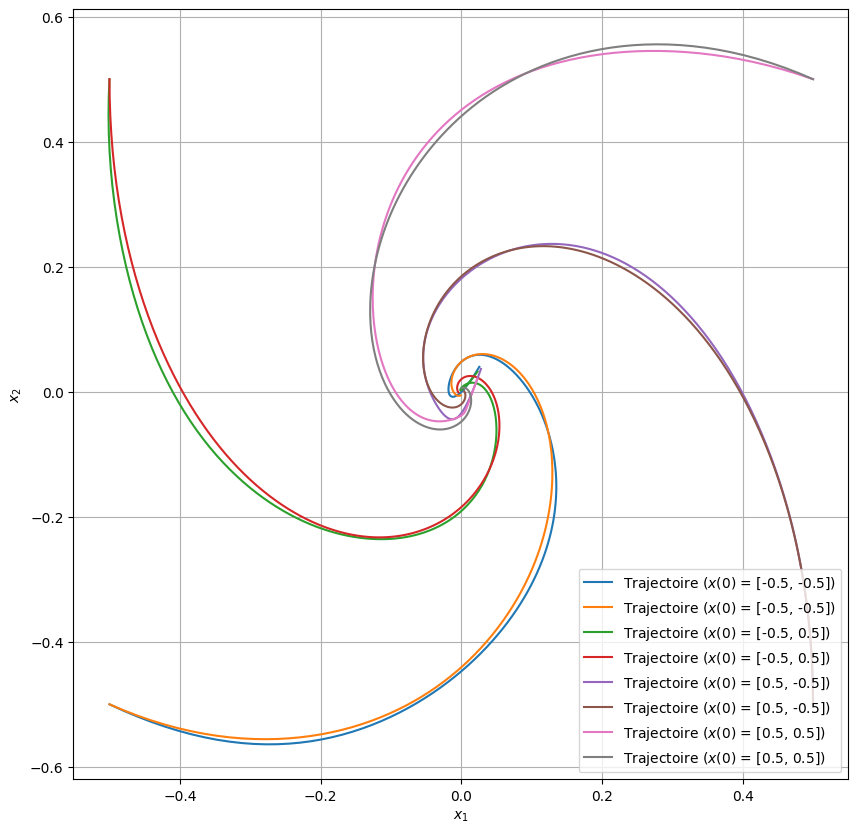

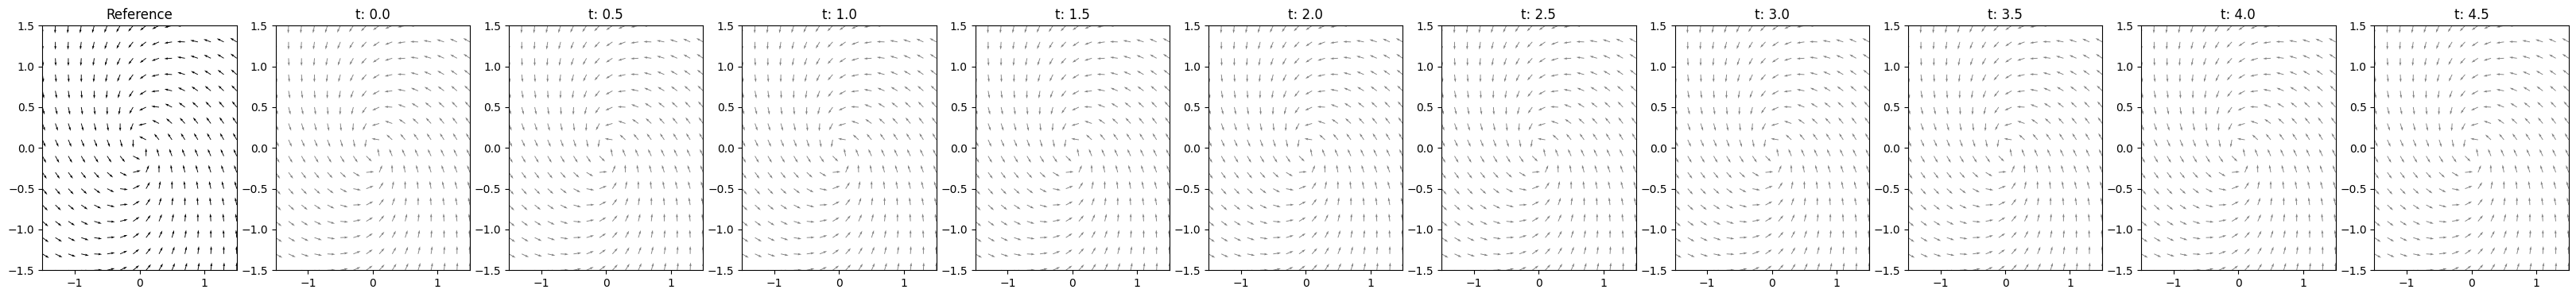

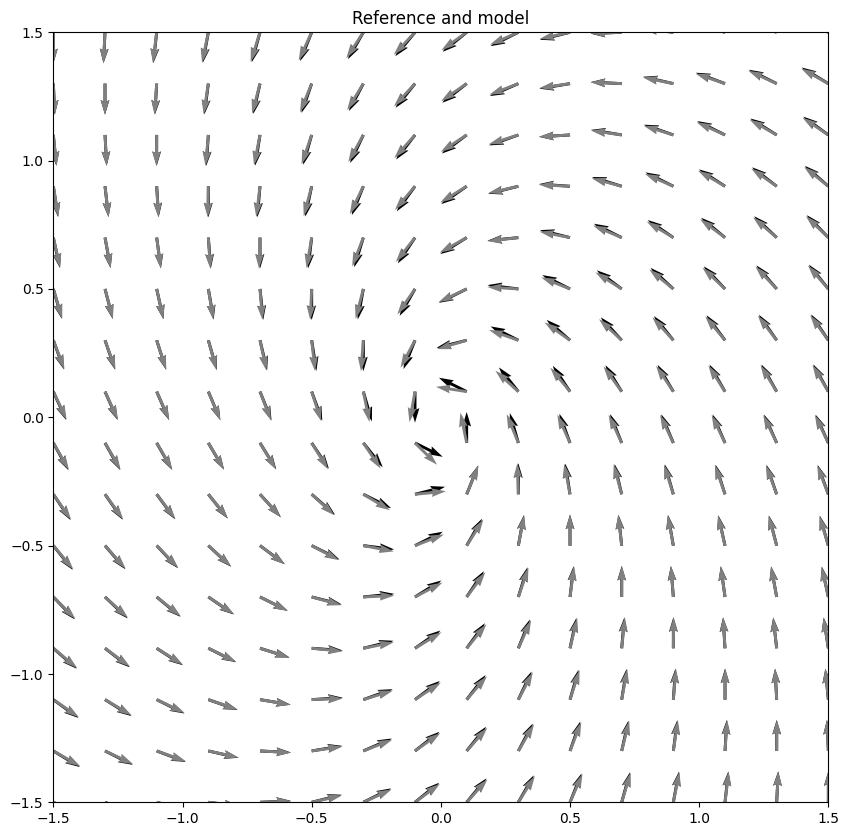

In [153]:
plt.figure(figsize=(10, 10))
for c_i in c_is:
    model_trajectory(model_A2, (0, T_MAX), c_i)
    true_trajectory_A(A, (0, T_MAX), c_i)
plt.grid()
plt.savefig('trajectories_pinn2.jpg')
plt.show()
fig, ax = plt.subplots(1, int(T_MAX*2)+1, figsize=(T_MAX*2*4 + 1, 4))
true_phase_portrait_A(A, ax[0])
for t in np.arange(0, T_MAX, .5):
    model_phase_portrait(model_A2, ax[int(t*2)+1], t)
plt.savefig('phase_portrait_through_time_pinn2.jpg')
plt.show()
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
true_phase_portrait_A(A, ax)
model_phase_portrait(model_A2, ax, 0)
ax.set_title("Reference and model")
plt.savefig('phase_portrait_pinn2.jpg')
plt.show()

## Parametric solution

In [24]:
class ParametricModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.K = nn.Parameter(torch.zeros(2, 2))

    def forward(self, t, t0, x1_0, x2_0):
        tau = t - t0
        Ktau = self.K.unsqueeze(0) * tau.unsqueeze(-1)
        Phi = torch.matrix_exp(Ktau)
        return (Phi @ torch.concatenate([x1_0, x2_0], axis=-1).unsqueeze(-1)).squeeze(-1)

from pcgrad import PCGrad

n_points = 5000
n_epochs = 1000

model = ParametricModel()
optimizer = optim.Adam(model.parameters(), lr=1e-2)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=200, min_lr=1e-5)

for _ in (pbar:=tqdm(range(n_epochs))):
    optimizer.zero_grad()
    t0 = torch.rand((n_points, 1), requires_grad=True) * T_MAX
    t1 = t0 + torch.rand((n_points, 1), requires_grad=True) * (T_MAX-t0)
    t = t1 + torch.rand((n_points, 1), requires_grad=True) * (T_MAX-t1)
    x1_0 = (torch.rand((n_points, 1), requires_grad=True)-0.5) * 8.
    x2_0 = (torch.rand((n_points, 1), requires_grad=True)-0.5) * 8.
    dt = (torch.rand((n_points, 1), requires_grad=True))
    loss1 = loss_physics(model, t, t0, x1_0, x2_0)
    loss1.backward()
    optimizer.step()
    scheduler.step(loss1.item())
    pbar.set_description(f"Loss Physics: {loss1.item():.4e}")

  0%|          | 0/1000 [00:00<?, ?it/s]

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/torch/utils/_device.py:103: UserWarning: The operator 'aten::linalg_matrix_exp' is not currently supported on the MPS backend and will fall back to run on the CPU. This may have performance implications. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/mps/MPSFallback.mm:15.)
  return func(*args, **kwargs)


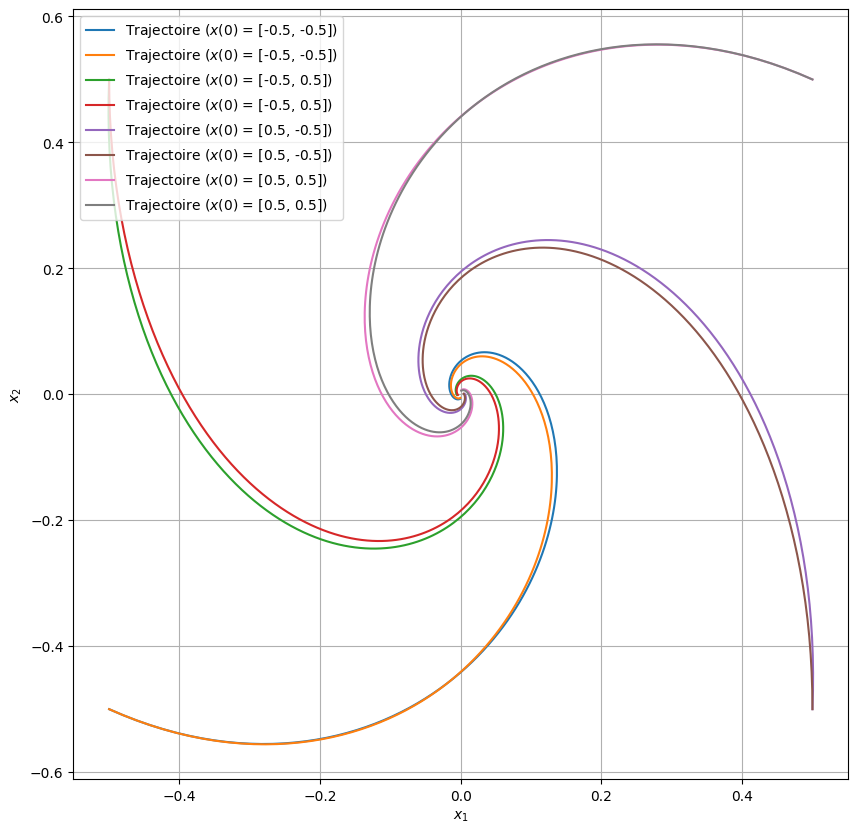

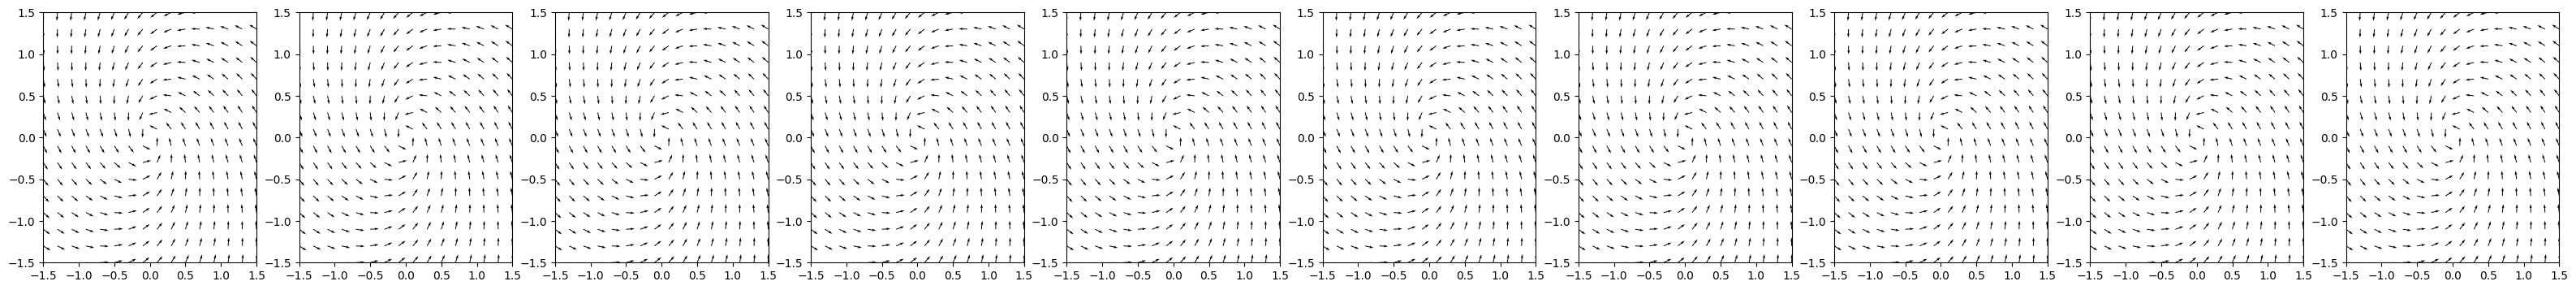

In [25]:
plt.figure(figsize=(10, 10))
for c_i in c_is:
    model_trajectory(model, (0, T_MAX), c_i)
    true_trajectory(A, (0, T_MAX), c_i)
plt.grid()
plt.show()
fig, ax = plt.subplots(1, int(T_MAX*2), figsize=(T_MAX*2*4, 4))
for t in np.arange(0, T_MAX, 0.5):
    model_phase_portrait(model, ax[int(t*2)], t)
plt.show()

# Non-linear

In [155]:
def true_trajectory_f(f, interval: list[int], c_i: list[float], ax=None) -> None:
    ax = ax or plt.gca()
    sol = solve_ivp(f, interval, c_i, t_eval=np.linspace(interval[0], interval[1], 250))
    ax.plot(sol.y[0, :], sol.y[1, :], label="Trajectoire ("+r"$x(0)$"+f" = {c_i})")
    ax.set_xlabel(r"$x_1$")
    ax.set_ylabel(r"$x_2$")
    ax.legend()


def true_phase_portrait_f(f, xlim=(-3.5, 3.5), ylim=(-3.5, 3.5), n=16, vector_scale=25, ax=None):
    ax = ax or plt.gca()
    x1, x2 = np.meshgrid(np.linspace(*xlim, n), np.linspace(*ylim, n))
    x1_values, x2_values = f(x1, x2)
    norms = np.sqrt(x1_values**2 + x2_values**2)
    norms[norms == 0] = 1
    x1_normalized = x1_values / norms
    x2_normalized = x2_values / norms
    ax.quiver(x1, x2, x1_normalized, x2_normalized, scale=vector_scale)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.grid()

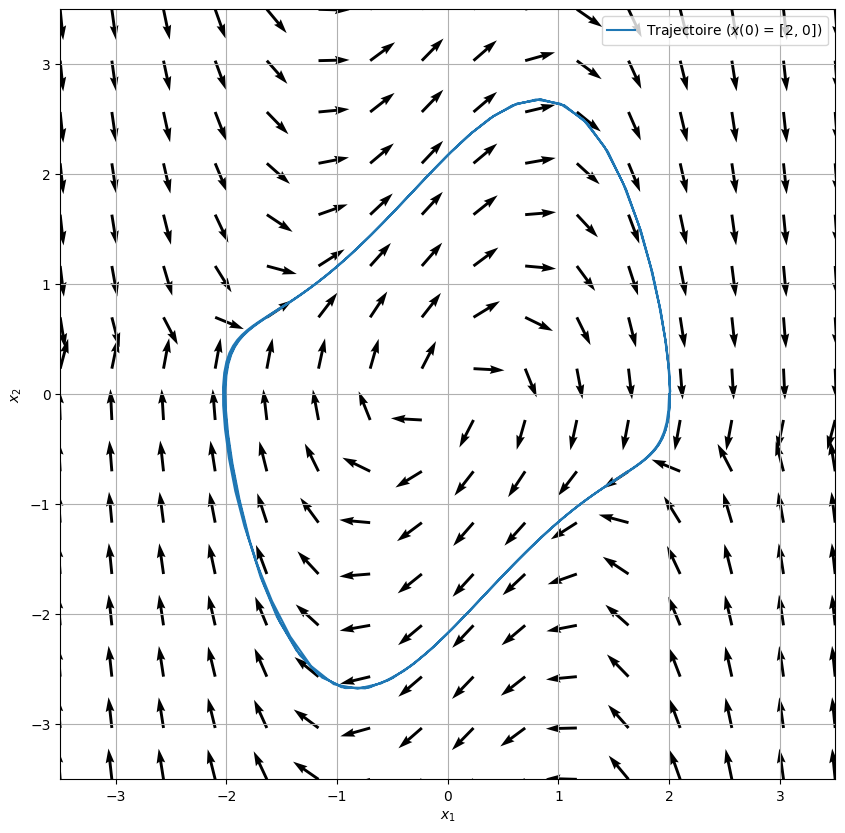

In [156]:
def vdp(t, x, mu=1.0):
    return [x[1], mu*(1 - x[0]**2)*x[1] - x[0]]

plt.figure(figsize=(10, 10))
true_trajectory_f(vdp, [0, 20], [2, 0])
true_phase_portrait_f(lambda x1, x2: (x2, 1.0*(1 - x1**2)*x2 - x1))

In [157]:
class TransitionPINN_VDP(nn.Module):
    def __init__(self, layer_size=32):
        super().__init__()
        self.l1 = nn.Linear(3, layer_size)
        self.l2 = nn.Linear(layer_size, layer_size)
        self.l3 = nn.Linear(layer_size, layer_size)
        self.l6 = nn.Linear(layer_size, 2)
        self.activation = nn.Tanh()

    def forward(self, t, t0, x1_0, x2_0):
        tau = t - t0
        inputs = torch.concatenate([tau, x1_0, x2_0], axis=-1)
        x = self.activation(self.l1(inputs))
        x = self.activation(self.l2(x))
        x = self.activation(self.l3(x))
        return tau * self.l6(x) + torch.concatenate([x1_0, x2_0], axis=-1)

def loss_physics_VDP(model, t, t0, x1_0, x2_0, mu=1.):
    x1x2 = model(t, t0, x1_0, x2_0)
    x1, x2 = x1x2[:, 0:1], x1x2[:, 1:2]
    dx1_dt = torch.autograd.grad(x1, t, grad_outputs=torch.ones_like(t), create_graph=True)[0]
    dx2_dt = torch.autograd.grad(x2, t, grad_outputs=torch.ones_like(t), create_graph=True)[0]
    r1 = dx1_dt - x2
    r2 = dx2_dt - (mu * (1 - x1**2) * x2 - x1)
    return torch.mean(r1**2) + torch.mean(r2**2)

In [158]:
n_points = 5000
n_epochs = 10000

torch.random.manual_seed(0)
model_VDP = TransitionPINN_VDP()
optimizer = optim.Adam(model_VDP.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=200, min_lr=1e-5)

for _ in (pbar:=tqdm(range(n_epochs))):
    optimizer.zero_grad()
    t0 = torch.rand((n_points, 1), requires_grad=True) * T_MAX
    t1 = t0 + torch.rand((n_points, 1), requires_grad=True) * (T_MAX-t0)
    t = t1 + torch.rand((n_points, 1), requires_grad=True) * (T_MAX-t1)
    x1_0 = (torch.rand((n_points, 1), requires_grad=True)-0.5) * 8.
    x2_0 = (torch.rand((n_points, 1), requires_grad=True)-0.5) * 8.
    dt = (torch.rand((n_points, 1), requires_grad=True))
    loss1 = loss_physics_VDP(model, t, t0, x1_0, x2_0)
    loss2 = composition_loss(model, t, t0, t1, x1_0, x2_0)
    (loss1).backward()
    optimizer.step()
    scheduler.step(loss1.item())
    pbar.set_description(f"Loss Physics: {loss1.item():.4e}, Loss Composition: {loss2.item():.4e}")

  0%|          | 0/10000 [00:00<?, ?it/s]

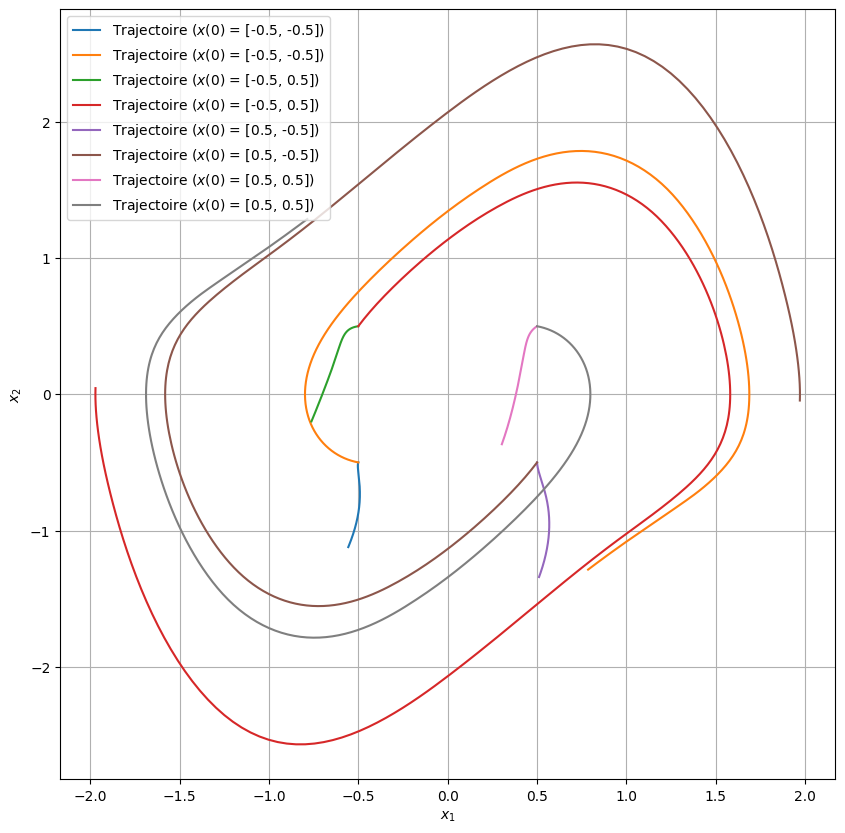

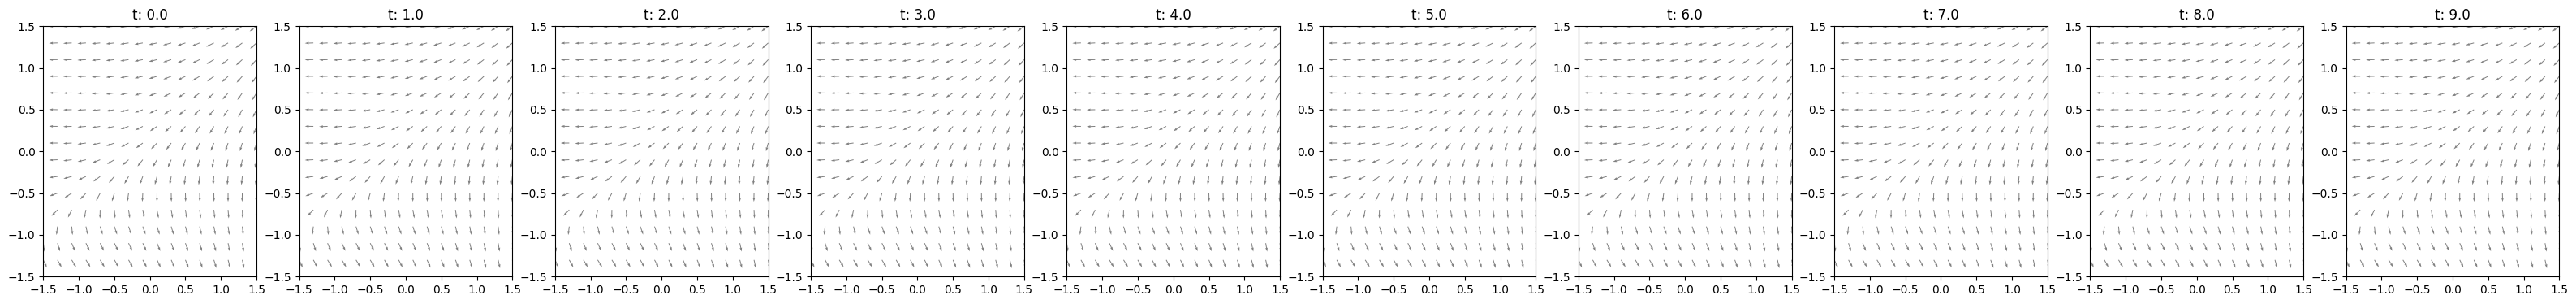

In [160]:
plt.figure(figsize=(10, 10))
for c_i in c_is:
    model_trajectory(model_VDP, (0, T_MAX), c_i)
    true_trajectory_f(vdp, [0, T_MAX], c_i)
plt.grid()
plt.show()
fig, ax = plt.subplots(1, int(T_MAX*2), figsize=(T_MAX*2*4, 4))
for t in np.arange(0, T_MAX*2, 1.):
    model_phase_portrait(model_VDP, ax[int(t)], t)
plt.show()

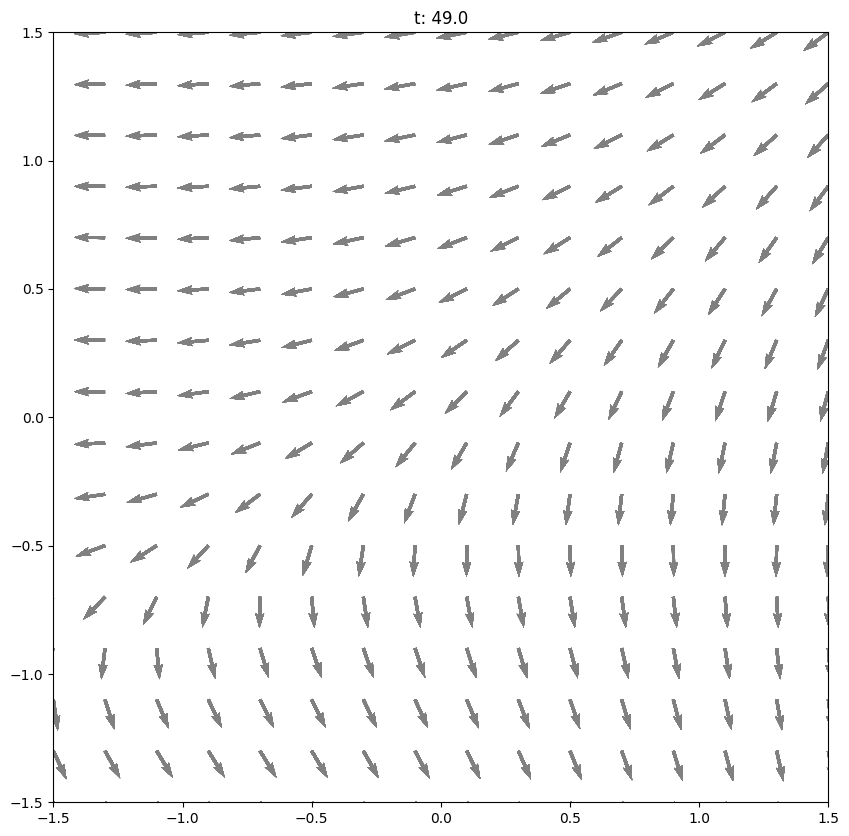

In [161]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
for t in np.arange(0, T_MAX*10, 1.):
    model_phase_portrait(model_VDP, ax, t)
plt.show()